# MACE-POLAR-1 models

In [1]:
from pathlib import Path
import gc, numpy as np, pandas as pd
from tqdm import tqdm
from ase.io import read
from mace.calculators import mace_polar

try:
    import torch
except Exception:
    torch = None

# ============================================================
# SETTINGS
# ============================================================
DATATYPE = "Barrier Height"
TAG = DATATYPE.replace(" ", "_")
UNIT = "kcal/mol"

MODELS = {
    "mace-polar-1-s": "polar-1-s",
    "mace-polar-1-m": "polar-1-m",
    "mace-polar-1-l": "polar-1-l",
}

DEVICE = "cuda" if torch is not None and torch.cuda.is_available() else "cpu"
DTYPE = "float64"
EV_TO_KCAL = 23.06054783

REUSE_EXISTING_MOLECULE_FILE = True
SAVE_EVERY = 20

# ============================================================
# PATHS
# ============================================================
def find_root():
    p = Path.cwd()
    for q in [p, p.parent]:
        if all((q / x).exists() for x in ["Analysis", "Info", "xyz_files", "qchem_inputs"]):
            return q
    raise FileNotFoundError("Run from GSCDB root folder or from GSCDB/Analysis.")

ROOT = find_root()
A, I, X, Q = ROOT / "Analysis", ROOT / "Info", ROOT / "xyz_files", ROOT / "qchem_inputs"
FIG = A / "Figures"
FIG.mkdir(exist_ok=True)

mol_out = A / f"Molecule_Energies_MACE_POLAR_Datatype_{TAG}_ALL3.csv"
mol_log = A / f"Molecule_Energies_MACE_POLAR_Datatype_{TAG}_ALL3_error_log.csv"
rxn_out = A / f"Reaction_Energies_with_MACE_POLAR_Datatype_{TAG}_ALL3.csv"
val_out = A / f"Results_values_with_MACE_POLAR_Datatype_{TAG}_ALL3.csv"
err_out = A / f"Results_errors_with_MACE_POLAR_Datatype_{TAG}_ALL3.csv"

mae_out = A / f"Errors_per_set_MAE_MACE_POLAR_Datatype_{TAG}_ALL3.csv"
rmse_out = A / f"Errors_per_set_RMSE_MACE_POLAR_Datatype_{TAG}_ALL3.csv"
metric_out = A / f"Errors_per_set_Metric_MACE_POLAR_Datatype_{TAG}_ALL3.csv"
rel_out = A / f"Relative_metric_per_set_MACE_POLAR_Datatype_{TAG}_ALL3.csv"
long_out = A / f"{TAG}_MACE_POLAR_ALL3_per_set_metrics_long.csv"
summary_out = A / f"{TAG}_MACE_POLAR_ALL3_Datatype_Summary.csv"

print("ROOT:", ROOT)
print("DEVICE:", DEVICE)
print("DATATYPE:", DATATYPE)

# ============================================================
# HELPERS
# ============================================================
def reset_calc(calc):
    try: calc.reset()
    except Exception: pass
    try: calc.results = {}
    except Exception: pass
    try: calc.atoms = None
    except Exception: pass

def read_qchem_state(qf):
    charge, spin = 0, 1
    if not qf.exists():
        return charge, spin

    lines = qf.read_text(errors="ignore").splitlines()
    for i, line in enumerate(lines):
        if line.strip().lower() == "$molecule":
            j = i + 1
            while j < len(lines) and not lines[j].strip():
                j += 1
            if j < len(lines):
                p = lines[j].split()
                if len(p) >= 2:
                    charge, spin = int(float(p[0])), int(float(p[1]))
            break
    return charge, spin

def prepare_atoms(mol):
    xf, qf = X / f"{mol}.xyz", Q / f"{mol}.in"

    if not xf.exists():
        raise FileNotFoundError(f"Missing xyz file: {xf}")

    charge, spin = read_qchem_state(qf)
    atoms = read(xf)

    charge = int(float(atoms.info.get("charge", charge)))
    spin = int(float(atoms.info.get("multiplicity", atoms.info.get("spin", spin))))

    atoms.info["charge"] = charge
    atoms.info["spin"] = spin

    # Barrier Height is not an electric-field dataset.
    atoms.info["external_field"] = np.array([0.0, 0.0, 0.0], dtype=float)

    return atoms, charge, spin

def mols_from_stoich(st):
    return [p.strip() for p in str(st).split(",")][1::2]

def reaction_energy_kcal(st, df_mol, col):
    p = [x.strip() for x in str(st).split(",")]
    e_ev = 0.0

    for i in range(0, len(p), 2):
        coef, mol = float(p[i]), p[i + 1]

        if mol not in df_mol.index or pd.isna(df_mol.loc[mol, col]):
            return np.nan

        e_ev += coef * float(df_mol.loc[mol, col])

    return e_ev * EV_TO_KCAL

def pooled_metrics(ref, pred):
    d = pd.DataFrame({"x": ref, "y": pred}).dropna()
    x = d["x"].to_numpy(float)
    y = d["y"].to_numpy(float)
    e = y - x

    return {
        "N_points": len(x),
        "MAE": np.mean(np.abs(e)) if len(x) else np.nan,
        "RMSE": np.sqrt(np.mean(e ** 2)) if len(x) else np.nan,
        "Pearson_r": np.corrcoef(x, y)[0, 1] if len(x) > 1 else np.nan,
    }

# ============================================================
# LOAD BASE FILES
# ============================================================
df_eval = pd.read_csv(I / "DatasetEval.csv", index_col=0)
df_info = pd.read_csv(I / "Datasets.csv", index_col=0)
df_rxn_all = pd.read_csv(A / "Reaction_Energies.csv", index_col=0)
df_val_all = pd.read_csv(A / "Results_values.csv", index_col=0)
df_std = pd.read_csv(I / "Standard_errors.csv", index_col=0)

datatype_datasets = df_info.index[df_info["Datatype"] == DATATYPE].tolist()
ev = df_eval[df_eval["Dataset"].isin(datatype_datasets)].copy()

rxn_base = df_rxn_all.loc[ev.index].copy()
val_base = df_val_all.loc[ev.index].copy()

print("\nDatasets in this Datatype:")
print(datatype_datasets)
print("Number of datasets:", len(datatype_datasets))
print("Number of data points:", len(ev))

if len(ev) == 0:
    raise ValueError("No data found. Check whether the Datatype string is exactly 'Barrier Height'.")

all_mols = sorted({m for st in ev["Stoichiometry"] for m in mols_from_stoich(st)})
print("Unique molecules:", len(all_mols))

# ============================================================
# MOLECULE TABLE
# ============================================================
if mol_out.exists() and REUSE_EXISTING_MOLECULE_FILE:
    df_mol = pd.read_csv(mol_out, index_col=0)
    print("\nReusing existing molecule-energy file:")
    print(mol_out)
else:
    rows, missing_xyz = [], []

    for mol in all_mols:
        if not (X / f"{mol}.xyz").exists():
            missing_xyz.append(mol)
            continue

        atoms, charge, spin = prepare_atoms(mol)
        rows.append({
            "Molecule": mol,
            "charge": charge,
            "spin": spin,
            "num_atoms": len(atoms),
        })

    if missing_xyz:
        print("First missing xyz files:", missing_xyz[:20])
        raise FileNotFoundError(f"{len(missing_xyz)} xyz files are missing.")

    df_mol = pd.DataFrame(rows).set_index("Molecule")

for col in MODELS:
    if col not in df_mol.columns:
        df_mol[col] = np.nan

# ============================================================
# MACE-POLAR MOLECULAR ENERGIES
# ============================================================
errors = []

for col, model in MODELS.items():
    print(f"\nLoading {col} -> {model}")
    calc = mace_polar(model=model, device=DEVICE, default_dtype=DTYPE)

    for n, mol in enumerate(tqdm(all_mols, desc=col), start=1):
        if REUSE_EXISTING_MOLECULE_FILE and mol in df_mol.index and pd.notna(df_mol.loc[mol, col]):
            continue

        try:
            atoms, charge, spin = prepare_atoms(mol)
            reset_calc(calc)
            atoms.calc = calc

            df_mol.loc[mol, "charge"] = charge
            df_mol.loc[mol, "spin"] = spin
            df_mol.loc[mol, "num_atoms"] = len(atoms)
            df_mol.loc[mol, col] = float(atoms.get_potential_energy())

        except Exception as exc:
            df_mol.loc[mol, col] = np.nan
            errors.append({"Molecule": mol, "Model": col, "Error": repr(exc)})

        if n % SAVE_EVERY == 0:
            df_mol.to_csv(mol_out)

    df_mol.to_csv(mol_out)
    del calc
    gc.collect()

    if torch is not None and torch.cuda.is_available():
        torch.cuda.empty_cache()

pd.DataFrame(errors).to_csv(mol_log, index=False)
df_mol.to_csv(mol_out)

print("\nMolecule-energy missing values:")
print(df_mol[list(MODELS)].isna().sum())

if len(errors):
    print("\nFirst MACE errors:")
    print(pd.DataFrame(errors).head(20).to_string(index=False))

# ============================================================
# REACTION ENERGIES
# ============================================================
df_rxn = rxn_base.copy()

for rid, row in tqdm(ev.iterrows(), total=len(ev), desc="Barrier Height reaction energies"):
    for col in MODELS:
        df_rxn.loc[rid, col] = reaction_energy_kcal(row["Stoichiometry"], df_mol, col)

df_rxn.to_csv(rxn_out)

print("\nReaction-energy check:")
for col in MODELS:
    print(
        col,
        "| NaN:", df_rxn[col].isna().sum(),
        "| exact zeros:", np.isclose(df_rxn[col].fillna(np.nan), 0.0, equal_nan=False).sum(),
        "| unique:", df_rxn[col].nunique(),
        "| min/max:", df_rxn[col].min(), df_rxn[col].max(),
    )

# ============================================================
# RESULTS VALUES AND ERRORS
# ============================================================
df_val = val_base.copy()

# Barrier Height remains kcal/mol.
for col in MODELS:
    df_val[col] = df_rxn[col]

df_val.to_csv(val_out)

df_err = df_val.copy()
for col in [c for c in df_val.columns if c not in ["Dataset", "Reaction", "Reference"]]:
    df_err[col] = pd.to_numeric(df_val[col], errors="coerce") - pd.to_numeric(df_val["Reference"], errors="coerce")

df_err.to_csv(err_out)

# ============================================================
# DATASET-LEVEL MAE, RMSE, METRIC ERROR, NER / MRE
# For Barrier Height, analyze.ipynb default metric = MAE.
# ============================================================
EVAL_COLS = ["wB97M-V", *MODELS.keys()]

mae_rows, rmse_rows, metric_rows, long_rows = [], [], [], []

for dataset, g_val in df_val.groupby("Dataset"):
    g_err = df_err.loc[g_val.index]
    std_metric = float(df_std.loc[dataset, "Metric"])

    mae_row = {"Dataset": dataset, "Datatype": DATATYPE}
    rmse_row = {"Dataset": dataset, "Datatype": DATATYPE}
    metric_row = {"Dataset": dataset, "Datatype": DATATYPE}

    for col in EVAL_COLS:
        err = pd.to_numeric(g_err[col], errors="coerce")
        complete = err.notna().all()
        n_total = len(err)
        n_used = int(err.notna().sum())

        if complete:
            mae = float(np.mean(np.abs(err)))
            rmse = float(np.sqrt(np.mean(err ** 2)))
            metric_error = mae
            ner = metric_error / std_metric
            status = "COMPLETE"
        else:
            mae = rmse = metric_error = ner = np.nan
            status = "INCOMPLETE"

        mae_row[col] = mae
        rmse_row[col] = rmse
        metric_row[col] = metric_error

        long_rows.append({
            "Dataset": dataset,
            "Datatype": DATATYPE,
            "Model": col,
            "Unit": UNIT,
            "N_total": n_total,
            "N_used": n_used,
            "Status": status,
            "MAE": mae,
            "RMSE": rmse,
            "Metric_Error": metric_error,
            "Standard_Error_Metric": std_metric,
            "NER": ner,
        })

    mae_rows.append(mae_row)
    rmse_rows.append(rmse_row)
    metric_rows.append(metric_row)

df_mae = pd.DataFrame(mae_rows).set_index("Dataset").sort_index()
df_rmse = pd.DataFrame(rmse_rows).set_index("Dataset").sort_index()
df_metric = pd.DataFrame(metric_rows).set_index("Dataset").sort_index()
df_long = pd.DataFrame(long_rows)

df_mae.to_csv(mae_out)
df_rmse.to_csv(rmse_out)
df_metric.to_csv(metric_out)

df_rel = df_metric.copy()
for col in EVAL_COLS:
    df_rel[col] = df_metric[col] / df_std.loc[df_metric.index, "Metric"]

df_rel.to_csv(rel_out)
df_long.to_csv(long_out, index=False)

# ============================================================
# DATATYPE SUMMARY
# ============================================================
summary_rows = []

for col in EVAL_COLS:
    pm = pooled_metrics(df_val["Reference"], df_val[col])
    sub = df_long[df_long["Model"] == col]

    summary_rows.append({
        "Datatype": DATATYPE,
        "Model": col,
        "Unit": UNIT,
        "N_points": pm["N_points"],
        "N_datasets_total": len(sub),
        "N_datasets_complete": int((sub["Status"] == "COMPLETE").sum()),
        "N_datasets_incomplete": int((sub["Status"] == "INCOMPLETE").sum()),
        "Pooled_MAE": pm["MAE"],
        "Pooled_RMSE": pm["RMSE"],
        "Pearson_r": pm["Pearson_r"],
        "Mean_Set_MAE": sub["MAE"].mean(skipna=True),
        "Mean_Set_RMSE": sub["RMSE"].mean(skipna=True),
        "Mean_Relative_Error_NER": sub["NER"].mean(skipna=True),
    })

df_summary = pd.DataFrame(summary_rows)
df_summary.to_csv(summary_out, index=False)

print("\nDatatype summary:")
print(df_summary.to_string(index=False))

# ============================================================
# CHECK wB97M-V MRE AGAINST EXISTING Statistical_errors.csv
# ============================================================
stat_file = A / "Statistical_errors.csv"
row_candidates = [
    f"Mean {DATATYPE}",
    "Mean Barrier Height",
    "Mean BH",
]

if stat_file.exists():
    df_stat = pd.read_csv(stat_file, index_col=0)

    found = False
    for row_name in row_candidates:
        if row_name in df_stat.index and "wB97M-V" in df_stat.columns:
            our = df_summary.loc[df_summary["Model"] == "wB97M-V", "Mean_Relative_Error_NER"].iloc[0]
            old = df_stat.loc[row_name, "wB97M-V"]

            print("\nComparison with existing Statistical_errors.csv:")
            print("Row:", row_name)
            print(f"Our calculated wB97M-V MRE/NER : {our:.10f}")
            print(f"Statistical_errors.csv value   : {old:.10f}")
            print(f"Absolute difference            : {abs(our - old):.3e}")

            found = True
            break

    if not found:
        print("\nStatistical_errors.csv found, but no matching row was found.")
        print("Available rows containing 'Barrier' or 'BH':")
        print([r for r in df_stat.index if "Barrier" in str(r) or str(r) == "BH" or "BH" in str(r)][:30])
else:
    print("\nNo Analysis/Statistical_errors.csv found. Skipped direct comparison.")

print("\nSaved files:")
for f in [mol_out, mol_log, rxn_out, val_out, err_out, mae_out, rmse_out, metric_out, rel_out, long_out, summary_out]:
    print(f)

/home/campus.ncl.ac.uk/c5062080/MScProject/.venv/lib/python3.13/site-packages/e3nn/o3/_wigner.py:10: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  _Jd, _W3j_flat, _W3j_indices = torch.load(os.path.join(os.path.dirname(__file__), 'constants.pt'))


cuequivariance or cuequivariance_torch is not available. Cuequivariance acceleration will be disabled.
ROOT: /home/campus.ncl.ac.uk/c5062080/MScProject/GSCDB
DEVICE: cuda
DATATYPE: Barrier Height

Datasets in this Datatype:
['BH28', 'BH46', 'BH876', 'BHDIV7', 'BHPERI11', 'BHROT27', 'CRBH14', 'DBH22', 'INV23', 'ORBH35', 'PX9', 'WCPT26']
Number of datasets: 12
Number of data points: 1124
Unique molecules: 2125

Loading mace-polar-1-s -> polar-1-s
Using MACE-Polar model for MACECalculator with /home/campus.ncl.ac.uk/c5062080/.cache/mace/MACEPOLAR1Smodel


/home/campus.ncl.ac.uk/c5062080/MScProject/.venv/lib/python3.13/site-packages/mace/calculators/mace.py:226: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)
mace-polar-1-s: 100%|██████████| 2125/2125 [02:11<00:00, 16.15it/s]
/home/campus.ncl.ac.uk/c5062080/MScProject/.venv/lib/python3.13/site-packages/mace/calculators/mace.py:226: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)



Loading mace-polar-1-m -> polar-1-m
Using MACE-Polar model for MACECalculator with /home/campus.ncl.ac.uk/c5062080/.cache/mace/MACEPOLAR1Mmodel


mace-polar-1-m: 100%|██████████| 2125/2125 [05:58<00:00,  5.92it/s]
/home/campus.ncl.ac.uk/c5062080/MScProject/.venv/lib/python3.13/site-packages/mace/calculators/mace.py:226: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)



Loading mace-polar-1-l -> polar-1-l
Using MACE-Polar model for MACECalculator with /home/campus.ncl.ac.uk/c5062080/.cache/mace/MACEPOLAR1Lmodel


mace-polar-1-l: 100%|██████████| 2125/2125 [14:14<00:00,  2.49it/s]



Molecule-energy missing values:
mace-polar-1-s    0
mace-polar-1-m    0
mace-polar-1-l    0
dtype: int64


Barrier Height reaction energies: 100%|██████████| 1124/1124 [00:00<00:00, 2711.11it/s]


Reaction-energy check:
mace-polar-1-s | NaN: 0 | exact zeros: 0 | unique: 1124 | min/max: -83.33900633511342 165.20350681623066
mace-polar-1-m | NaN: 0 | exact zeros: 0 | unique: 1124 | min/max: -90.45893868300215 154.02005934641323
mace-polar-1-l | NaN: 0 | exact zeros: 0 | unique: 1124 | min/max: -94.04243935537482 152.8118879750411

Datatype summary:
      Datatype          Model     Unit  N_points  N_datasets_total  N_datasets_complete  N_datasets_incomplete  Pooled_MAE  Pooled_RMSE  Pearson_r  Mean_Set_MAE  Mean_Set_RMSE  Mean_Relative_Error_NER
Barrier Height        wB97M-V kcal/mol      1124                12                   12                      0    1.346344     1.856186   0.995460      1.283467       1.710124                 1.061578
Barrier Height mace-polar-1-s kcal/mol      1124                12                   12                      0    6.670928    11.050819   0.882203      7.042811      10.301627                 5.801192
Barrier Height mace-polar-1-m kcal/mol  

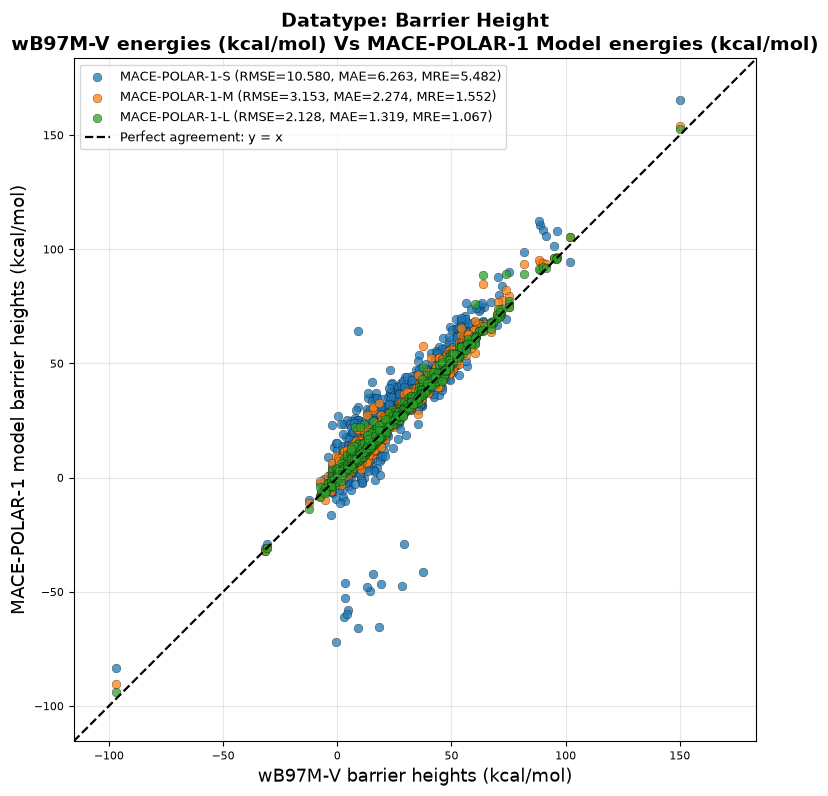

Saved: /home/campus.ncl.ac.uk/c5062080/MScProject/GSCDB/Analysis/Figures/Barrier_Height_01_wB97M-V_vs_MACE_POLAR_ALL3_V30_style.png


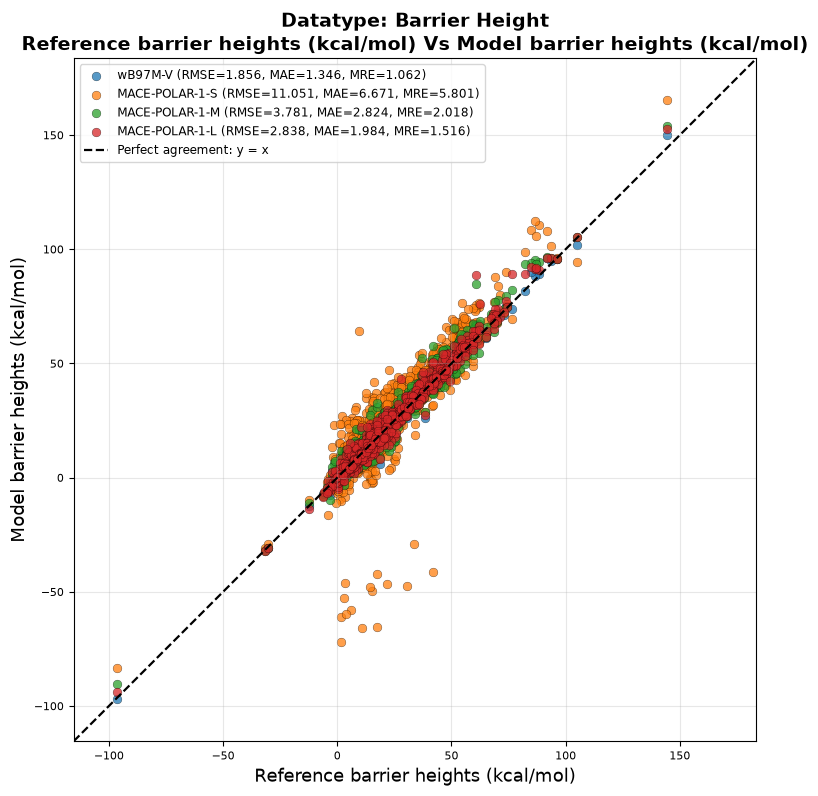

Saved: /home/campus.ncl.ac.uk/c5062080/MScProject/GSCDB/Analysis/Figures/Barrier_Height_02_Reference_vs_All_Models_V30_style.png


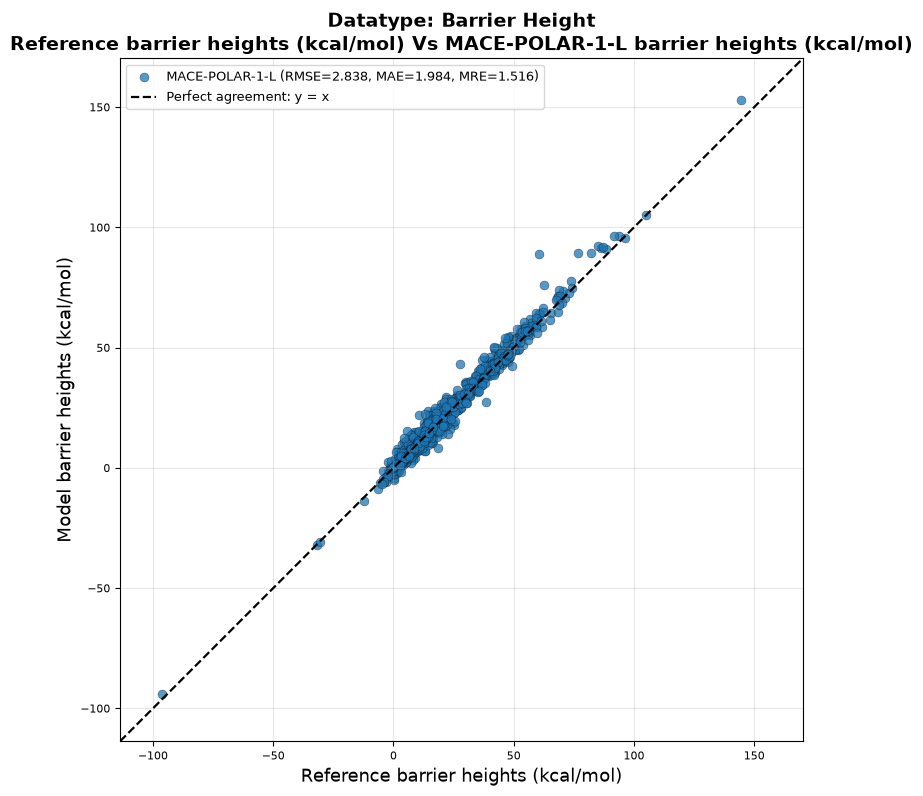

Saved: /home/campus.ncl.ac.uk/c5062080/MScProject/GSCDB/Analysis/Figures/Barrier_Height_03_Reference_vs_mace-polar-1-l_V30_style.png


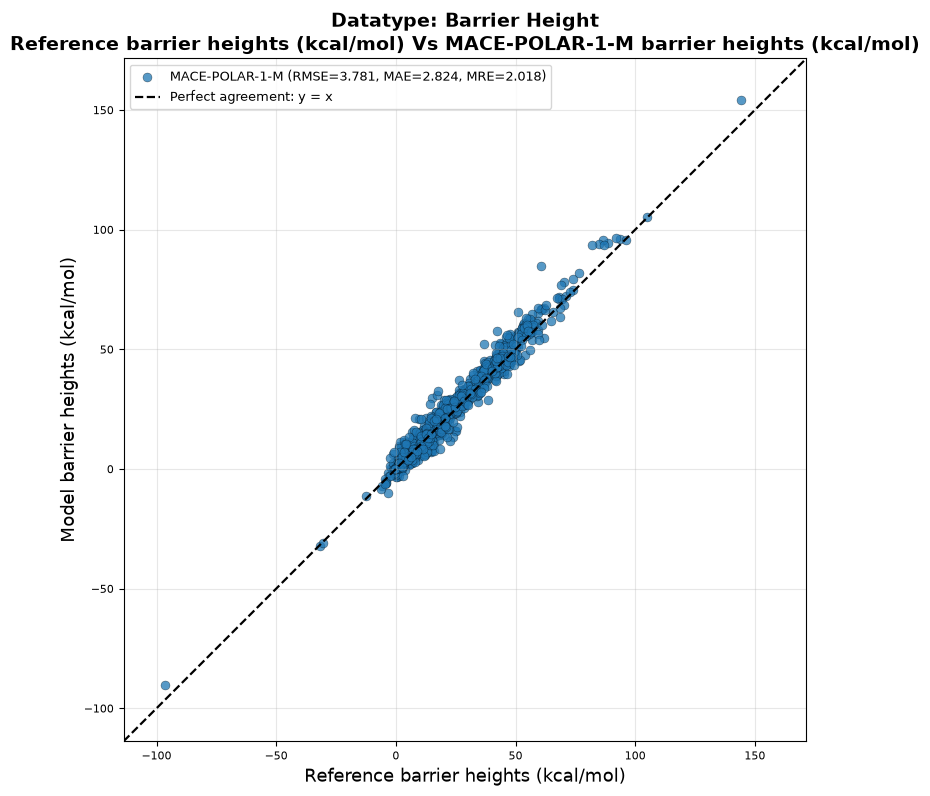

Saved: /home/campus.ncl.ac.uk/c5062080/MScProject/GSCDB/Analysis/Figures/Barrier_Height_04_Reference_vs_mace-polar-1-m_V30_style.png


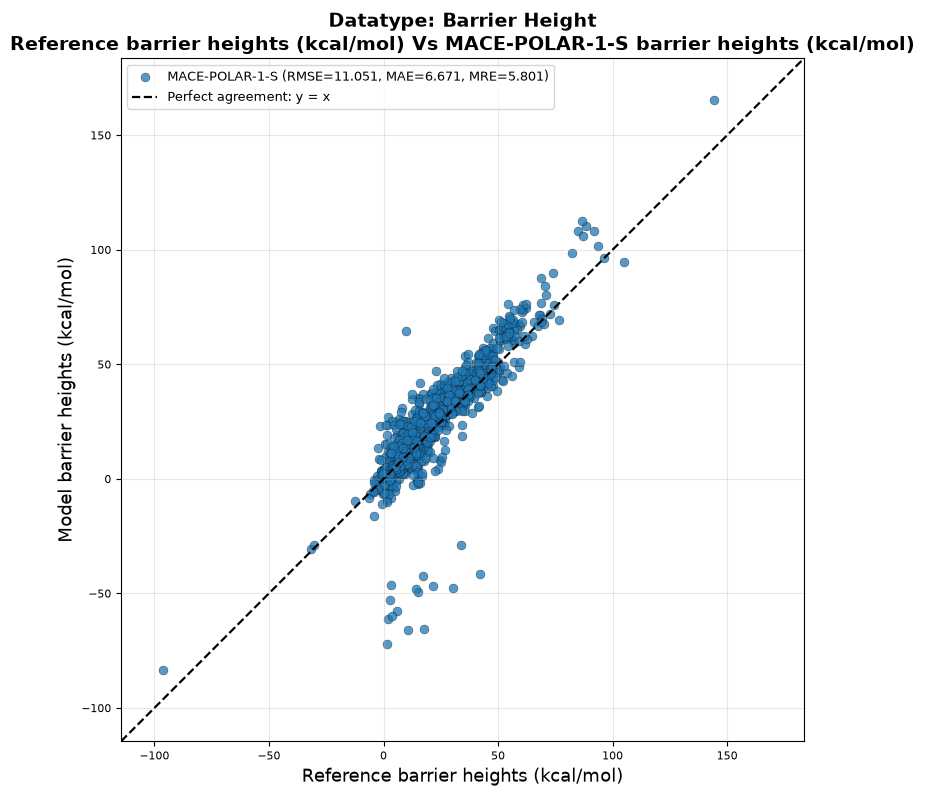

Saved: /home/campus.ncl.ac.uk/c5062080/MScProject/GSCDB/Analysis/Figures/Barrier_Height_05_Reference_vs_mace-polar-1-s_V30_style.png


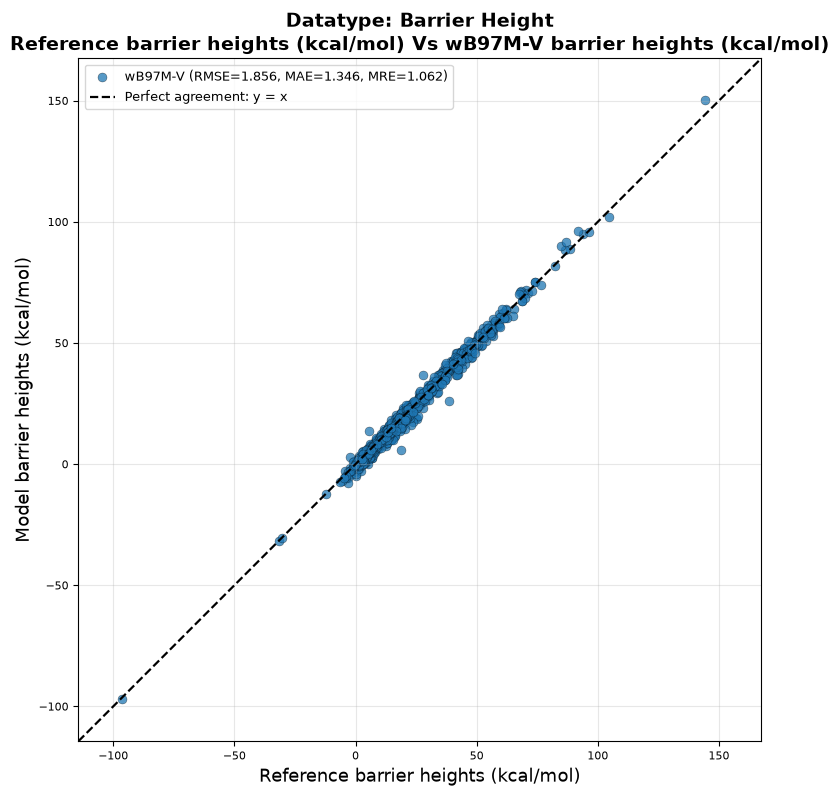

Saved: /home/campus.ncl.ac.uk/c5062080/MScProject/GSCDB/Analysis/Figures/Barrier_Height_06_Reference_vs_wB97M-V_V30_style.png

Saved plot metrics:
/home/campus.ncl.ac.uk/c5062080/MScProject/GSCDB/Analysis/Barrier_Height_V30_style_correlation_plot_metrics.csv

Plot metrics:
                   Plot_Type    X_axis         Y_axis          Model      RMSE      MAE      MRE  Pearson_r    N
             wB97M-V_vs_MACE   wB97M-V mace-polar-1-s MACE-POLAR-1-S 10.579819 6.263262 5.481738   0.894175 1124
             wB97M-V_vs_MACE   wB97M-V mace-polar-1-m MACE-POLAR-1-M  3.152881 2.273867 1.552078   0.990543 1124
             wB97M-V_vs_MACE   wB97M-V mace-polar-1-l MACE-POLAR-1-L  2.127571 1.319467 1.066771   0.995172 1124
            Reference_vs_All Reference        wB97M-V        wB97M-V  1.856186 1.346344 1.061578   0.995460 1124
            Reference_vs_All Reference mace-polar-1-s MACE-POLAR-1-S 11.050819 6.670928 5.801192   0.882203 1124
            Reference_vs_All Reference mace-pola

In [3]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# Barrier Height correlation plots like V30 Frequency plots
# ============================================================

DATATYPE = "Barrier Height"
TAG = DATATYPE.replace(" ", "_")
UNIT = "kcal/mol"

ROOT = Path.cwd()
if not (ROOT / "Analysis").exists():
    ROOT = ROOT.parent

A = ROOT / "Analysis"
I = ROOT / "Info"
FIG = A / "Figures"
FIG.mkdir(exist_ok=True)

val_file = A / f"Results_values_with_MACE_POLAR_Datatype_{TAG}_ALL3.csv"
summary_file = A / f"{TAG}_MACE_POLAR_ALL3_Datatype_Summary.csv"
std_file = I / "Standard_errors.csv"

df = pd.read_csv(val_file, index_col=0)
summary = pd.read_csv(summary_file)
std = pd.read_csv(std_file, index_col=0)

MODELS_ALL = ["wB97M-V", "mace-polar-1-s", "mace-polar-1-m", "mace-polar-1-l"]
MACE_MODELS = ["mace-polar-1-s", "mace-polar-1-m", "mace-polar-1-l"]

LABELS = {
    "wB97M-V": "wB97M-V",
    "mace-polar-1-s": "MACE-POLAR-1-S",
    "mace-polar-1-m": "MACE-POLAR-1-M",
    "mace-polar-1-l": "MACE-POLAR-1-L",
}

# ============================================================
# Helper functions
# ============================================================

def point_metrics(x, y):
    d = pd.DataFrame({"x": x, "y": y}).dropna()
    x = d["x"].to_numpy(float)
    y = d["y"].to_numpy(float)
    e = y - x

    return {
        "N": len(x),
        "RMSE": np.sqrt(np.mean(e ** 2)),
        "MAE": np.mean(np.abs(e)),
        "Pearson_r": np.corrcoef(x, y)[0, 1] if len(x) > 1 else np.nan,
    }

def get_reference_mre(model):
    return float(
        summary.loc[
            summary["Model"] == model,
            "Mean_Relative_Error_NER"
        ].iloc[0]
    )

def get_wb97mv_relative_mre(model):
    """
    For the special wB97M-V vs MACE plot:
    MRE is calculated dataset-by-dataset as:

        MAE(model - wB97M-V) / Standard_errors.csv Metric

    Then averaged across Barrier Height datasets.

    This keeps the same NER denominator as GSCDB.
    """
    rows = []

    for dataset, g in df.groupby("Dataset"):
        if dataset not in std.index:
            continue

        d = g[["wB97M-V", model]].dropna()

        if len(d) != len(g):
            continue

        e = pd.to_numeric(d[model], errors="coerce") - pd.to_numeric(d["wB97M-V"], errors="coerce")
        mae = np.mean(np.abs(e))
        standard_error = float(std.loc[dataset, "Metric"])

        rows.append(mae / standard_error)

    return float(np.mean(rows)) if rows else np.nan

def limits_from_columns(dataframe, x_col, y_cols):
    values = [pd.to_numeric(dataframe[x_col], errors="coerce").dropna().to_numpy(float)]

    for col in y_cols:
        values.append(pd.to_numeric(dataframe[col], errors="coerce").dropna().to_numpy(float))

    values = np.concatenate(values)
    pad = 0.07 * (values.max() - values.min())

    return values.min() - pad, values.max() + pad

plot_metric_rows = []

# ============================================================
# Plot 1:
# wB97M-V energies vs all three MACE-POLAR model energies
# ============================================================

lo, hi = limits_from_columns(df, "wB97M-V", MACE_MODELS)

plt.figure(figsize=(10, 8))

for model in MACE_MODELS:
    m = point_metrics(df["wB97M-V"], df[model])
    mre = get_wb97mv_relative_mre(model)

    plot_metric_rows.append({
        "Plot_Type": "wB97M-V_vs_MACE",
        "X_axis": "wB97M-V",
        "Y_axis": model,
        "Model": LABELS[model],
        "RMSE": m["RMSE"],
        "MAE": m["MAE"],
        "MRE": mre,
        "Pearson_r": m["Pearson_r"],
        "N": m["N"],
    })

    plt.scatter(
        df["wB97M-V"],
        df[model],
        s=40,
        alpha=0.75,
        edgecolors="black",
        linewidths=0.25,
        label=f"{LABELS[model]} (RMSE={m['RMSE']:.3f}, MAE={m['MAE']:.3f}, MRE={mre:.3f})",
    )

plt.plot(
    [lo, hi],
    [lo, hi],
    "--",
    color="black",
    linewidth=1.6,
    label="Perfect agreement: y = x",
)

plt.xlim(lo, hi)
plt.ylim(lo, hi)
plt.gca().set_aspect("equal", adjustable="box")

plt.xlabel("wB97M-V barrier heights (kcal/mol)", fontsize=13)
plt.ylabel("MACE-POLAR-1 model barrier heights (kcal/mol)", fontsize=13)

plt.title(
    "Datatype: Barrier Height\n"
    "wB97M-V energies (kcal/mol) Vs MACE-POLAR-1 Model energies (kcal/mol)",
    fontsize=14,
    fontweight="bold",
)

plt.grid(alpha=0.3)
plt.legend(fontsize=9)
plt.tight_layout()

out = FIG / f"{TAG}_01_wB97M-V_vs_MACE_POLAR_ALL3_V30_style.png"
plt.savefig(out, dpi=300)
plt.show()
print("Saved:", out)

# ============================================================
# Plot 2:
# Reference energies vs wB97M-V + all three MACE-POLAR models
# ============================================================

lo, hi = limits_from_columns(df, "Reference", MODELS_ALL)

plt.figure(figsize=(10, 8))

for model in MODELS_ALL:
    m = point_metrics(df["Reference"], df[model])
    mre = get_reference_mre(model)

    plot_metric_rows.append({
        "Plot_Type": "Reference_vs_All",
        "X_axis": "Reference",
        "Y_axis": model,
        "Model": LABELS[model],
        "RMSE": m["RMSE"],
        "MAE": m["MAE"],
        "MRE": mre,
        "Pearson_r": m["Pearson_r"],
        "N": m["N"],
    })

    plt.scatter(
        df["Reference"],
        df[model],
        s=40,
        alpha=0.75,
        edgecolors="black",
        linewidths=0.25,
        label=f"{LABELS[model]} (RMSE={m['RMSE']:.3f}, MAE={m['MAE']:.3f}, MRE={mre:.3f})",
    )

plt.plot(
    [lo, hi],
    [lo, hi],
    "--",
    color="black",
    linewidth=1.6,
    label="Perfect agreement: y = x",
)

plt.xlim(lo, hi)
plt.ylim(lo, hi)
plt.gca().set_aspect("equal", adjustable="box")

plt.xlabel("Reference barrier heights (kcal/mol)", fontsize=13)
plt.ylabel("Model barrier heights (kcal/mol)", fontsize=13)

plt.title(
    "Datatype: Barrier Height\n"
    "Reference barrier heights (kcal/mol) Vs Model barrier heights (kcal/mol)",
    fontsize=14,
    fontweight="bold",
)

plt.grid(alpha=0.3)
plt.legend(fontsize=8.5)
plt.tight_layout()

out = FIG / f"{TAG}_02_Reference_vs_All_Models_V30_style.png"
plt.savefig(out, dpi=300)
plt.show()
print("Saved:", out)

# ============================================================
# Plots 3, 4, 5:
# Reference vs individual MACE-POLAR models
# Order: L, M, S, like your V30 images
# ============================================================

individual_order = [
    "mace-polar-1-l",
    "mace-polar-1-m",
    "mace-polar-1-s",
]

for plot_number, model in zip([3, 4, 5], individual_order):
    m = point_metrics(df["Reference"], df[model])
    mre = get_reference_mre(model)

    plot_metric_rows.append({
        "Plot_Type": "Reference_vs_Individual_MACE",
        "X_axis": "Reference",
        "Y_axis": model,
        "Model": LABELS[model],
        "RMSE": m["RMSE"],
        "MAE": m["MAE"],
        "MRE": mre,
        "Pearson_r": m["Pearson_r"],
        "N": m["N"],
    })

    lo, hi = limits_from_columns(df, "Reference", [model])

    plt.figure(figsize=(10, 8))

    plt.scatter(
        df["Reference"],
        df[model],
        s=42,
        alpha=0.75,
        edgecolors="black",
        linewidths=0.25,
        label=f"{LABELS[model]} (RMSE={m['RMSE']:.3f}, MAE={m['MAE']:.3f}, MRE={mre:.3f})",
    )

    plt.plot(
        [lo, hi],
        [lo, hi],
        "--",
        color="black",
        linewidth=1.6,
        label="Perfect agreement: y = x",
    )

    plt.xlim(lo, hi)
    plt.ylim(lo, hi)
    plt.gca().set_aspect("equal", adjustable="box")

    plt.xlabel("Reference barrier heights (kcal/mol)", fontsize=13)
    plt.ylabel("Model barrier heights (kcal/mol)", fontsize=13)

    plt.title(
        f"Datatype: Barrier Height\n"
        f"Reference barrier heights (kcal/mol) Vs {LABELS[model]} barrier heights (kcal/mol)",
        fontsize=14,
        fontweight="bold",
    )

    plt.grid(alpha=0.3)
    plt.legend(fontsize=9)
    plt.tight_layout()

    out = FIG / f"{TAG}_0{plot_number}_Reference_vs_{model}_V30_style.png"
    plt.savefig(out, dpi=300)
    plt.show()
    print("Saved:", out)

# ============================================================
# Plot 6:
# Reference vs wB97M-V
# ============================================================

model = "wB97M-V"
m = point_metrics(df["Reference"], df[model])
mre = get_reference_mre(model)

plot_metric_rows.append({
    "Plot_Type": "Reference_vs_wB97M-V",
    "X_axis": "Reference",
    "Y_axis": model,
    "Model": LABELS[model],
    "RMSE": m["RMSE"],
    "MAE": m["MAE"],
    "MRE": mre,
    "Pearson_r": m["Pearson_r"],
    "N": m["N"],
})

lo, hi = limits_from_columns(df, "Reference", [model])

plt.figure(figsize=(10, 8))

plt.scatter(
    df["Reference"],
    df[model],
    s=42,
    alpha=0.75,
    edgecolors="black",
    linewidths=0.25,
    label=f"{LABELS[model]} (RMSE={m['RMSE']:.3f}, MAE={m['MAE']:.3f}, MRE={mre:.3f})",
)

plt.plot(
    [lo, hi],
    [lo, hi],
    "--",
    color="black",
    linewidth=1.6,
    label="Perfect agreement: y = x",
)

plt.xlim(lo, hi)
plt.ylim(lo, hi)
plt.gca().set_aspect("equal", adjustable="box")

plt.xlabel("Reference barrier heights (kcal/mol)", fontsize=13)
plt.ylabel("Model barrier heights (kcal/mol)", fontsize=13)

plt.title(
    "Datatype: Barrier Height\n"
    "Reference barrier heights (kcal/mol) Vs wB97M-V barrier heights (kcal/mol)",
    fontsize=14,
    fontweight="bold",
)

plt.grid(alpha=0.3)
plt.legend(fontsize=9)
plt.tight_layout()

out = FIG / f"{TAG}_06_Reference_vs_wB97M-V_V30_style.png"
plt.savefig(out, dpi=300)
plt.show()
print("Saved:", out)

# ============================================================
# Save metrics from all plots
# ============================================================

plot_metrics = pd.DataFrame(plot_metric_rows)
plot_metrics_out = A / f"{TAG}_V30_style_correlation_plot_metrics.csv"
plot_metrics.to_csv(plot_metrics_out, index=False)

print("\nSaved plot metrics:")
print(plot_metrics_out)

print("\nPlot metrics:")
print(plot_metrics.to_string(index=False))

# MACE-OMOL-0	models

In [4]:
# CELL 1 — MACE-OMOL-0 calculations for the complete Barrier Height datatype

from pathlib import Path
import re, gc, torch
import numpy as np
import pandas as pd
from ase import Atoms
from tqdm.auto import tqdm
from mace.calculators import mace_omol

# ---------------- Settings ----------------
DATATYPE = "Barrier Height"
H2K = 627.50947406
EV2H = 1 / 27.211386245988
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

MODELS = {
    "MACE-OMOL-0-100M": "extra_large",
    "MACE-OMOL-0-4M":
        "https://github.com/ACEsuit/mace-foundations/releases/download/"
        "mace_omol_0/mace-omol-0-extra-large-4M.model"
}

ROOT = Path.cwd().parent if Path.cwd().name == "Analysis" else Path.cwd()
INFO, QCHEM, ANALYSIS = ROOT/"Info", ROOT/"qchem_inputs", ROOT/"Analysis"
OUT = ROOT/"MACE_OMOL_results"/"Barrier_Height"
OUT.mkdir(parents=True, exist_ok=True)

print("Device:", DEVICE)

# ---------------- Select complete Barrier Height datatype ----------------
datasets = pd.read_csv(INFO/"Datasets.csv", index_col=0)
bh_sets = datasets.index[datasets["Datatype"].eq(DATATYPE)].tolist()

eval_df = pd.read_csv(INFO/"DatasetEval.csv", index_col=0)
bh = eval_df[eval_df["Dataset"].isin(bh_sets)].copy()

print(f"{len(bh_sets)} datasets | {len(bh)} Barrier Height points")

# ---------------- Helpers ----------------
def stoich(s):
    p = [x.strip() for x in s.split(",")]
    return [(float(p[i]), p[i+1]) for i in range(0, len(p), 2)]

def read_qchem(name):
    txt = (QCHEM/f"{name}.in").read_text(errors="ignore")
    lines = [x.strip() for x in re.search(
        r"\$molecule(.*?)\$end", txt, re.I | re.S
    ).group(1).splitlines() if x.strip()]

    charge, mult = map(lambda x: int(float(x)), lines[0].split()[:2])
    symbols, xyz = [], []

    for line in lines[1:]:
        p = line.split()
        sym = p[0].replace("@", "") if p else ""
        if len(p) >= 4 and re.fullmatch(r"[A-Za-z]{1,2}", sym):
            try:
                symbols.append(sym)
                xyz.append(list(map(float, p[1:4])))
            except ValueError:
                pass

    return Atoms(symbols, positions=xyz), charge, mult

def reaction_energy(s, energies):
    return sum(c * energies[m] for c, m in stoich(s)) * H2K

# ---------------- Unique molecules ----------------
species = sorted({
    molecule
    for s in bh["Stoichiometry"]
    for _, molecule in stoich(s)
})

print("Unique molecular structures:", len(species))

# ---------------- MACE-OMOL molecular energies ----------------
mol_energies = pd.DataFrame(index=species)

for name, model in MODELS.items():
    calc = mace_omol(model=model, device=DEVICE, default_dtype="float64")
    E = {}

    for molecule in tqdm(species, desc=name):
        atoms, charge, mult = read_qchem(molecule)
        atoms.info["charge"], atoms.info["spin"] = float(charge), float(mult)
        atoms.calc = calc
        E[molecule] = atoms.get_potential_energy() * EV2H

    mol_energies[name] = pd.Series(E)
    del calc
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

mol_energies.to_csv(OUT/"Barrier_Height_Molecule_Energies.csv")

# ---------------- Reconstruct Barrier Heights ----------------
results_df = pd.DataFrame(index=bh.index)
results_df["Dataset"] = bh["Dataset"]
results_df["Reference"] = bh["Reference"].astype(float) * H2K

for name in MODELS:
    E = mol_energies[name].to_dict()
    results_df[name] = [
        reaction_energy(s, E) for s in bh["Stoichiometry"]
    ]

# Existing wB97M-V values
gscdb_results = pd.read_csv(ANALYSIS/"Reaction_Energies.csv", index_col=0)
results_df["wB97M-V"] = gscdb_results["wB97M-V"].reindex(results_df.index)

# ---------------- Metrics ----------------
standard = pd.read_csv(INFO/"Standard_errors.csv", index_col=0)["Metric"]

def metrics(xcol, ycol):
    d = results_df[["Dataset", xcol, ycol]].dropna()
    e = d[ycol] - d[xcol]
    mre = np.mean([
        np.mean(np.abs(g[ycol] - g[xcol])) / standard.loc[ds]
        for ds, g in d.groupby("Dataset")
    ])
    return {
        "RMSE": np.sqrt(np.mean(e**2)),
        "MAE": np.mean(np.abs(e)),
        "MRE": mre
    }

metric_rows = []

for model in ["wB97M-V", *MODELS]:
    metric_rows.append({
        "Comparison": f"Reference vs {model}",
        **metrics("Reference", model)
    })

for model in MODELS:
    metric_rows.append({
        "Comparison": f"wB97M-V vs {model}",
        **metrics("wB97M-V", model)
    })

metrics_df = pd.DataFrame(metric_rows)

results_df.to_csv(OUT/"Barrier_Height_All_Results.csv")
metrics_df.to_csv(OUT/"Barrier_Height_Metrics.csv", index=False)

display(metrics_df)
display(results_df.head())

print(f"\nSaved in: {OUT}")

Device: cpu
12 datasets | 1124 Barrier Height points
Unique molecular structures: 2125
Using float64 for MACECalculator, recommended for geometry optimization.


c:\Users\91988\anaconda3\envs\mace-polar\Lib\site-packages\mace\calculators\mace.py:226: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)
MACE-OMOL-0-100M: 100%|██████████| 2125/2125 [1:16:05<00:00,  2.15s/it]


Using float64 for MACECalculator, recommended for geometry optimization.


c:\Users\91988\anaconda3\envs\mace-polar\Lib\site-packages\mace\calculators\mace.py:226: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)
MACE-OMOL-0-4M: 100%|██████████| 2125/2125 [1:15:15<00:00,  2.12s/it]


,Comparison,RMSE,MAE,MRE
0,Reference vs wB97M-V,1.856186,1.346344,1.061578
1,Reference vs MACE-OMOL-0-100M,3.446885,2.096259,1.499598
2,Reference vs MACE-OMOL-0-4M,8.144414,4.488602,2.508705
3,wB97M-V vs MACE-OMOL-0-100M,3.062867,1.636783,1.080617
4,wB97M-V vs MACE-OMOL-0-4M,7.719517,4.023158,2.224689


,Dataset,Reference,MACE-OMOL-0-100M,MACE-OMOL-0-4M,wB97M-V
Reaction,,,,,
BH28_BHDIV_1,BH28,56.955067,55.974864,53.988750,56.864131
BH28_BHDIV_2,BH28,50.095602,50.648120,51.109008,50.716834
BH28_BHDIV_3,BH28,65.559273,64.398025,64.959658,63.827054
BH28_BHPERI_4,BH28,35.014340,36.773501,36.527958,36.690550
BH28_BHPERI_5,BH28,30.999044,30.958504,32.279039,30.477149



Saved in: c:\Users\91988\Documents\GitHub\Accurate-Prediction-of-Molecular-Properties-with-Polarisable-MACE\MACE_OMOL_results\Barrier_Height


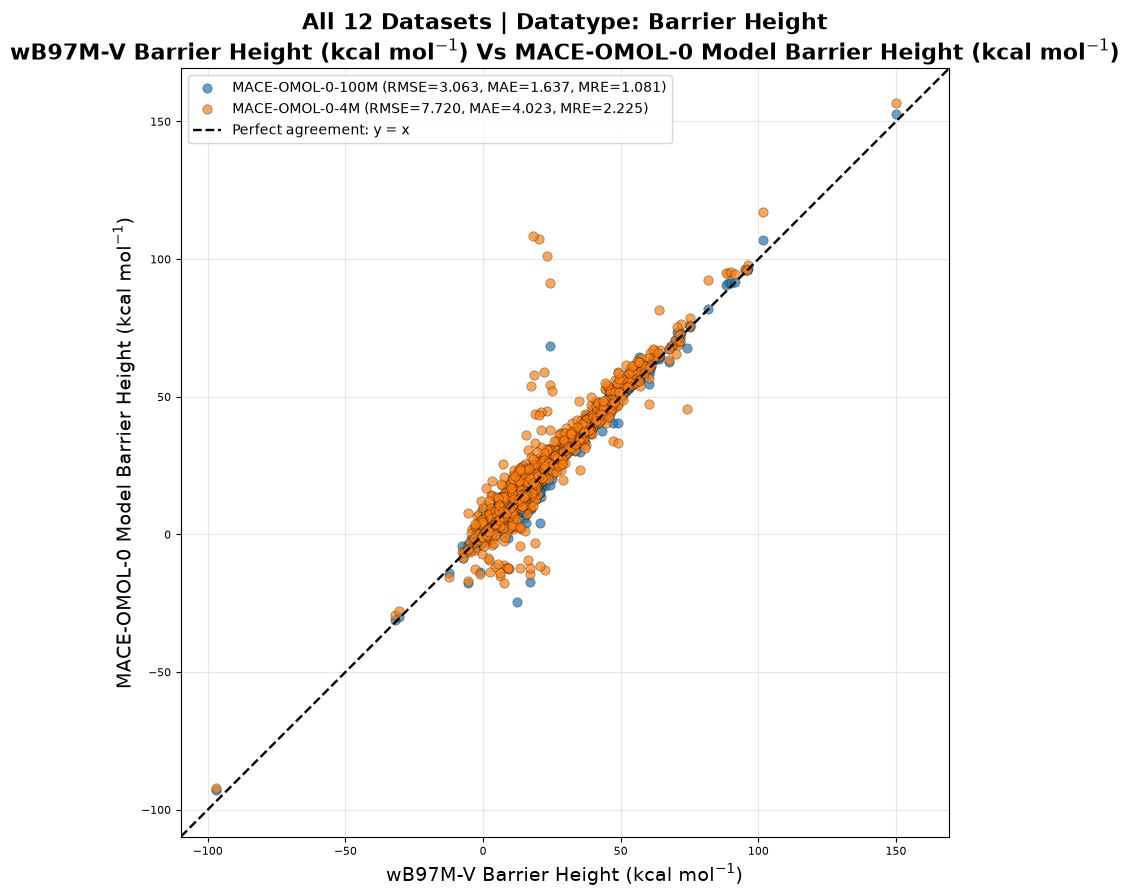

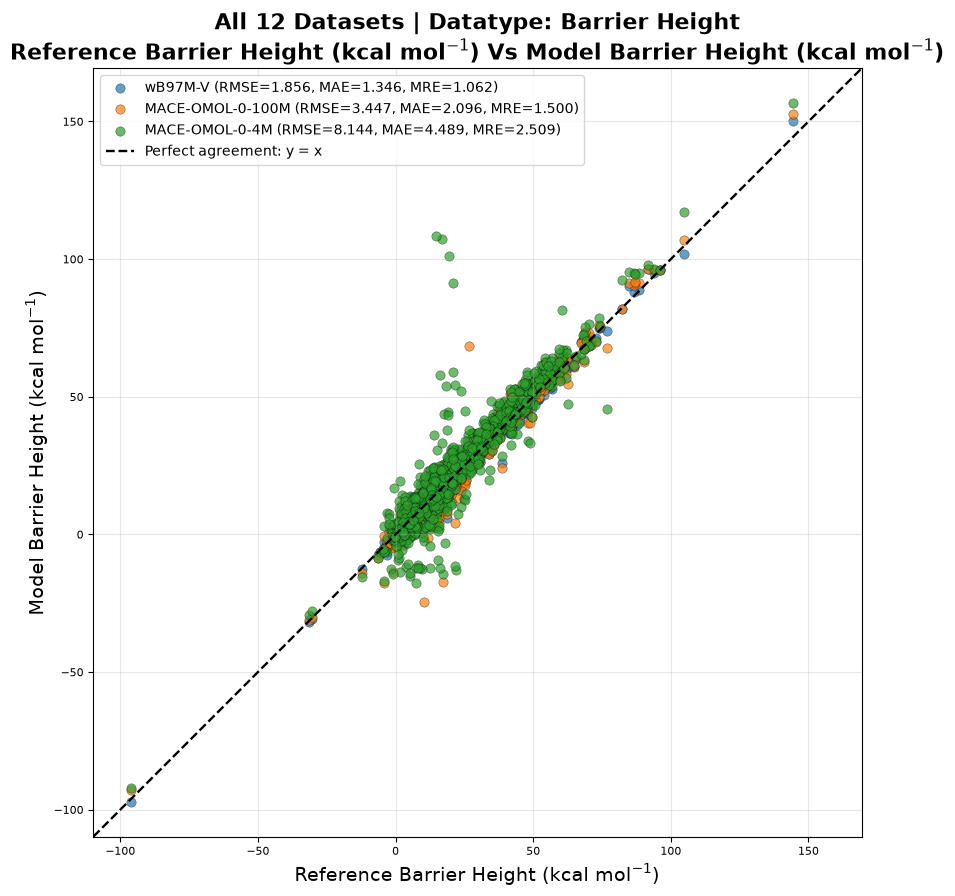

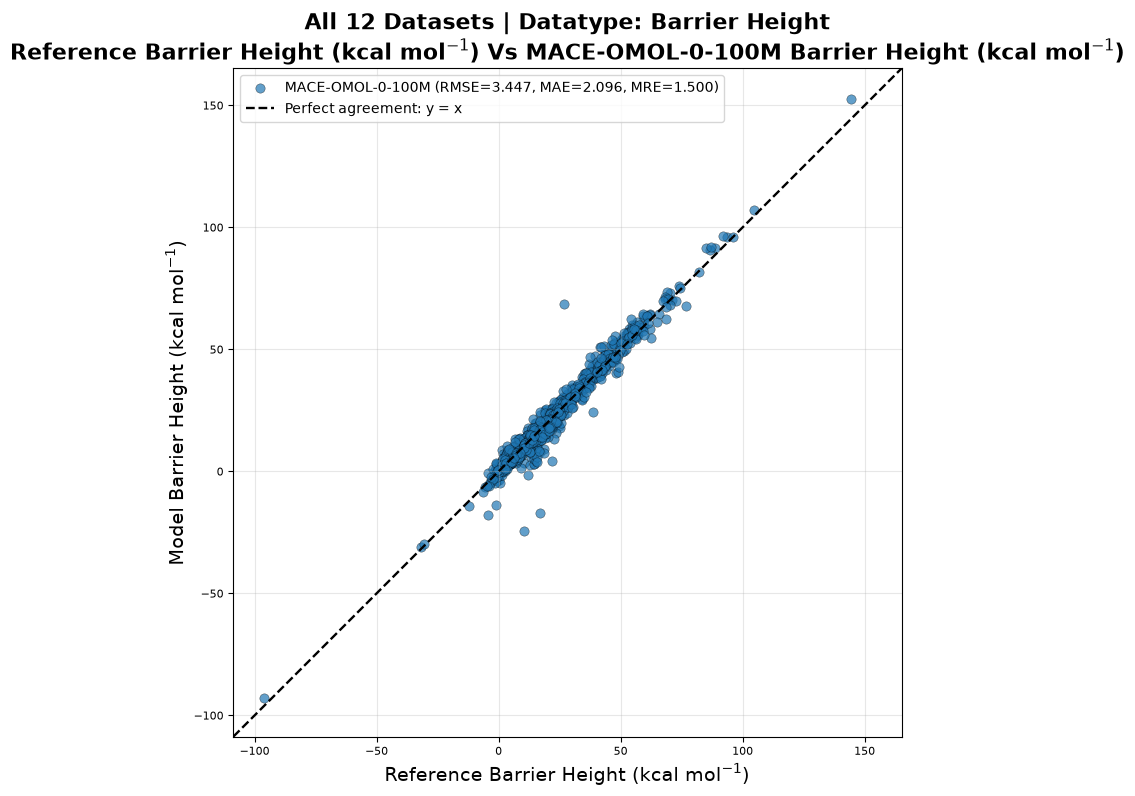

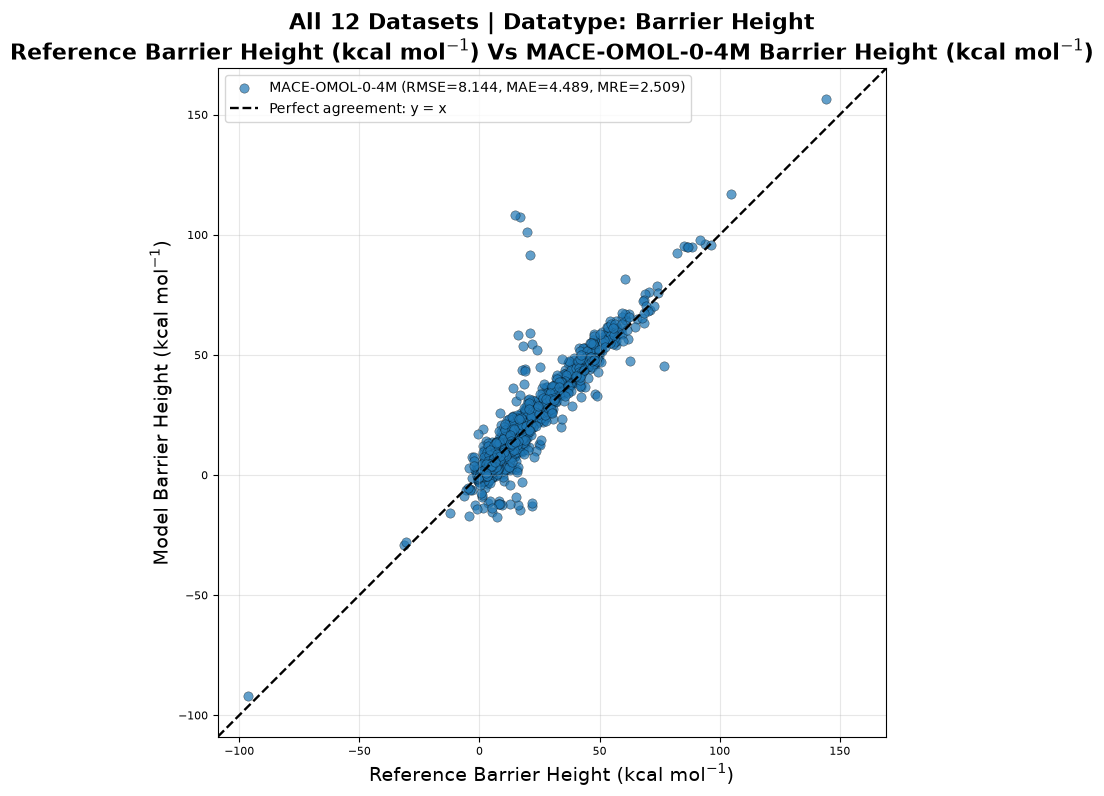

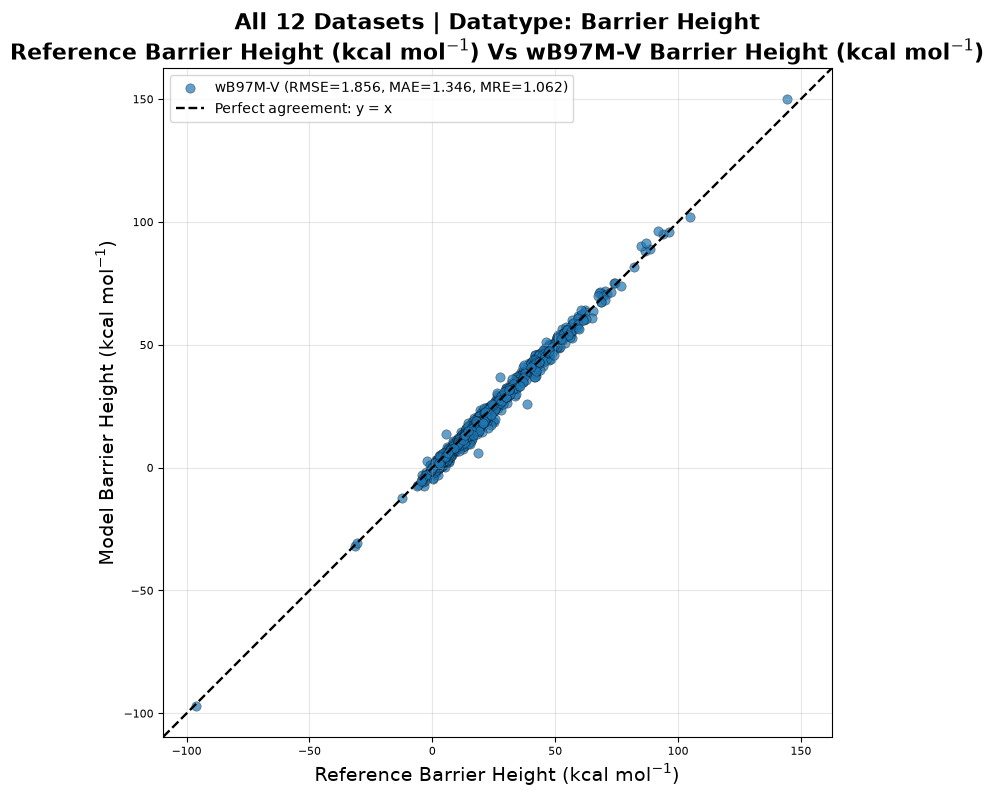

All plots saved in: c:\Users\91988\Documents\GitHub\Accurate-Prediction-of-Molecular-Properties-with-Polarisable-MACE\MACE_OMOL_results\Barrier_Height\Correlation_Plots


In [5]:
# CELL 2 — All Barrier Height correlation plots

import matplotlib.pyplot as plt
import numpy as np

PLOT_DIR = OUT/"Correlation_Plots"
PLOT_DIR.mkdir(exist_ok=True)

UNIT = r"kcal mol$^{-1}$"
NSETS = results_df["Dataset"].nunique()

def make_plot(xcol, ycols, filename, xlabel, ylabel, title, figsize=(12, 9)):
    fig, ax = plt.subplots(figsize=figsize)
    arrays = [results_df[xcol]]

    for ycol in ycols:
        s = metrics(xcol, ycol)
        ax.scatter(
            results_df[xcol], results_df[ycol],
            s=45, alpha=0.7, edgecolors="black", linewidths=0.3,
            label=f"{ycol} (RMSE={s['RMSE']:.3f}, MAE={s['MAE']:.3f}, MRE={s['MRE']:.3f})"
        )
        arrays.append(results_df[ycol])

    values = np.concatenate([np.asarray(a.dropna()) for a in arrays])
    lo, hi = values.min(), values.max()
    pad = 0.05 * (hi - lo)

    ax.plot(
        [lo-pad, hi+pad], [lo-pad, hi+pad],
        "k--", lw=1.7, label="Perfect agreement: y = x"
    )
    ax.set_xlim(lo-pad, hi+pad)
    ax.set_ylim(lo-pad, hi+pad)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel(xlabel, fontsize=14)
    ax.set_ylabel(ylabel, fontsize=14)
    ax.set_title(
        f"All {NSETS} Datasets | Datatype: {DATATYPE}\n{title}",
        fontsize=16, fontweight="bold"
    )
    ax.grid(alpha=0.3)
    ax.legend(loc="upper left", fontsize=10)
    plt.tight_layout()
    plt.savefig(PLOT_DIR/filename, dpi=300, bbox_inches="tight")
    plt.show()

# 1 — wB97M-V vs both MACE-OMOL-0 models
make_plot(
    "wB97M-V",
    ["MACE-OMOL-0-100M", "MACE-OMOL-0-4M"],
    "1_wB97M-V_vs_MACE-OMOL-0.png",
    f"wB97M-V Barrier Height ({UNIT})",
    f"MACE-OMOL-0 Model Barrier Height ({UNIT})",
    f"wB97M-V Barrier Height ({UNIT}) Vs MACE-OMOL-0 Model Barrier Height ({UNIT})"
)

# 2 — Reference vs all required models
make_plot(
    "Reference",
    ["wB97M-V", "MACE-OMOL-0-100M", "MACE-OMOL-0-4M"],
    "2_Reference_vs_All_Models.png",
    f"Reference Barrier Height ({UNIT})",
    f"Model Barrier Height ({UNIT})",
    f"Reference Barrier Height ({UNIT}) Vs Model Barrier Height ({UNIT})"
)

# 3–5 — Individual Reference correlations
single_plots = [
    ("MACE-OMOL-0-100M", "3_Reference_vs_MACE-OMOL-0-100M.png"),
    ("MACE-OMOL-0-4M",   "4_Reference_vs_MACE-OMOL-0-4M.png"),
    ("wB97M-V",           "5_Reference_vs_wB97M-V.png")
]

for model, filename in single_plots:
    make_plot(
        "Reference",
        [model],
        filename,
        f"Reference Barrier Height ({UNIT})",
        f"Model Barrier Height ({UNIT})",
        f"Reference Barrier Height ({UNIT}) Vs {model} Barrier Height ({UNIT})",
        figsize=(10, 8)
    )

print(f"All plots saved in: {PLOT_DIR}")

In [6]:
# ---------------- Per-dataset MAE, RMSE, MRE ----------------
model_cols = ["wB97M-V", *MODELS.keys()]
err = results_df[model_cols].sub(results_df["Reference"], axis=0)
groups = results_df["Dataset"]

mae = err.abs().groupby(groups).mean().reindex(bh_sets)
rmse = err.pow(2).groupby(groups).mean().pow(0.5).reindex(bh_sets)
mre = mae.div(standard.reindex(bh_sets), axis=0)   # Barrier Height metric = MAE

def save_metric(df, filename):
    df = df.copy()
    df.insert(0, "Datatype", DATATYPE)
    df.index.name = "Dataset"
    df.to_csv(OUT/filename)
    return df

mae_per_set = save_metric(
    mae, "Errors_per_set_MAE_MACE_OMOL_Datatype_Barrier_Height_ALL2.csv"
)
rmse_per_set = save_metric(
    rmse, "Errors_per_set_RMSE_MACE_OMOL_Datatype_Barrier_Height_ALL2.csv"
)
mre_per_set = save_metric(
    mre, "Relative_metric_per_set_MACE_OMOL_Datatype_Barrier_Height_ALL2.csv"
)

display(mae_per_set)
display(rmse_per_set)
display(mre_per_set)

,Datatype,wB97M-V,MACE-OMOL-0-100M,MACE-OMOL-0-4M
Dataset,,,,
BH28,Barrier Height,0.985091,1.460595,1.936211
BH46,Barrier Height,1.419317,2.343319,5.078114
BH876,Barrier Height,1.368165,2.122602,4.833404
BHDIV7,Barrier Height,1.472264,1.652551,3.997252
BHPERI11,Barrier Height,1.335941,1.207060,3.048839
BHROT27,Barrier Height,0.221744,0.246626,0.251650
CRBH14,Barrier Height,1.139680,0.725967,1.140965
DBH22,Barrier Height,1.174704,2.172065,4.391444
INV23,Barrier Height,1.058040,1.640264,2.327454


,Datatype,wB97M-V,MACE-OMOL-0-100M,MACE-OMOL-0-4M
Dataset,,,,
BH28,Barrier Height,1.285163,2.064728,2.329475
BH46,Barrier Height,1.841388,2.903359,6.364754
BH876,Barrier Height,1.804771,3.533088,8.754644
BHDIV7,Barrier Height,1.852918,2.135045,4.911147
BHPERI11,Barrier Height,1.629023,2.198523,3.244789
BHROT27,Barrier Height,0.298766,0.300775,0.306031
CRBH14,Barrier Height,1.346025,0.868480,1.510037
DBH22,Barrier Height,1.524812,2.760431,5.344937
INV23,Barrier Height,1.428791,2.113387,4.794419


,Datatype,wB97M-V,MACE-OMOL-0-100M,MACE-OMOL-0-4M
Dataset,,,,
BH28,Barrier Height,0.838411,1.243111,1.647908
BH46,Barrier Height,1.080336,1.783656,3.865290
BH876,Barrier Height,0.848269,1.316023,2.996733
BHDIV7,Barrier Height,1.274012,1.430023,3.458992
BHPERI11,Barrier Height,1.211910,1.094995,2.765781
BHROT27,Barrier Height,0.735468,0.817994,0.834658
CRBH14,Barrier Height,1.321611,0.841855,1.323102
DBH22,Barrier Height,0.973613,1.800241,3.639696
INV23,Barrier Height,0.940596,1.458194,2.069105


# MACE-MP-0b3 model

In [7]:
# CELL 1 — Entire Barrier Height datatype with MACE-MP-0b3

from pathlib import Path
import gc, torch, numpy as np, pandas as pd
from tqdm.auto import tqdm
from ase.io import read
from mace.calculators import mace_mp

DATATYPE, MODEL = "Barrier Height", "MACE-MP-0b3"
EV2KCAL, DEVICE = 23.06054783, "cuda" if torch.cuda.is_available() else "cpu"

ROOT = Path.cwd().parent if Path.cwd().name == "Analysis" else Path.cwd()
A, I, X = ROOT/"Analysis", ROOT/"Info", ROOT/"xyz_files"

info = pd.read_csv(I/"Datasets.csv", index_col=0)
sets = info.index[info["Datatype"].eq(DATATYPE)].tolist()

ev = pd.read_csv(I/"DatasetEval.csv", index_col=0)
ev = ev[ev["Dataset"].isin(sets)]

base = pd.read_csv(A/"Results_values.csv", index_col=0)
results_df = base.loc[ev.index, ["Dataset", "Reference", "wB97M-V"]].copy()

def stoich(s):
    p = [x.strip() for x in str(s).split(",")]
    return [(float(p[i]), p[i+1]) for i in range(0, len(p), 2)]

mols = sorted({m for s in ev["Stoichiometry"] for _, m in stoich(s)})
print(f"{len(sets)} datasets | {len(ev)} points | {len(mols)} molecules | {DEVICE}")

calc = mace_mp(model="medium-0b3", device=DEVICE, default_dtype="float64")
E = {}

for m in tqdm(mols, desc=MODEL):
    atoms = read(X/f"{m}.xyz")
    atoms.calc = calc
    E[m] = float(atoms.get_potential_energy())

del calc
gc.collect()
if torch.cuda.is_available(): torch.cuda.empty_cache()

pd.DataFrame({MODEL: E}).to_csv(A/"Molecule_Energies_MACE_MP_0b3_Barrier_Height.csv")

results_df[MODEL] = [
    sum(c * E[m] for c, m in stoich(s)) * EV2KCAL
    for s in ev["Stoichiometry"]
]
results_df.to_csv(A/"Reaction_Energies_MACE_MP_0b3_Barrier_Height.csv")

# ---------- Per-dataset MAE, RMSE, MRE ----------
models = ["wB97M-V", MODEL]
err = results_df[models].sub(results_df["Reference"], axis=0)
group = results_df["Dataset"]
std = pd.read_csv(I/"Standard_errors.csv", index_col=0)["Metric"]

mae = err.abs().groupby(group).mean().reindex(sets)
rmse = err.pow(2).groupby(group).mean().pow(0.5).reindex(sets)
mre = mae.div(std.reindex(sets), axis=0)       # Barrier Height metric = MAE

def save(df, name):
    df = df.copy()
    df.insert(0, "Datatype", DATATYPE)
    df.index.name = "Dataset"
    df.to_csv(A/name)
    return df

mae = save(mae, "Errors_per_set_MAE_MACE_MP_0b3_Datatype_Barrier_Height.csv")
rmse = save(rmse, "Errors_per_set_RMSE_MACE_MP_0b3_Datatype_Barrier_Height.csv")
mre = save(mre, "Relative_metric_per_set_MACE_MP_0b3_Datatype_Barrier_Height.csv")

display(mae)
display(rmse)
display(mre)

12 datasets | 1124 points | 2125 molecules | cpu
Using Materials Project MACE for MACECalculator with C:\Users\91988\.cache\mace/macemp0b3mediummodel
Using float64 for MACECalculator, which is slower but more accurate. Recommended for geometry optimization.


c:\Users\91988\anaconda3\envs\mace-polar\Lib\site-packages\mace\calculators\mace.py:226: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)
MACE-MP-0b3: 100%|██████████| 2125/2125 [18:03<00:00,  1.96it/s]


,Datatype,wB97M-V,MACE-MP-0b3
Dataset,,,
BH28,Barrier Height,0.985091,13.333756
BH46,Barrier Height,1.419317,21.258841
BH876,Barrier Height,1.368165,11.907518
BHDIV7,Barrier Height,1.472264,18.892371
BHPERI11,Barrier Height,1.335941,17.646903
BHROT27,Barrier Height,0.221744,2.381264
CRBH14,Barrier Height,1.139680,12.329811
DBH22,Barrier Height,1.174704,19.798847
INV23,Barrier Height,1.058040,9.340382


,Datatype,wB97M-V,MACE-MP-0b3
Dataset,,,
BH28,Barrier Height,1.285163,17.476371
BH46,Barrier Height,1.841388,26.088126
BH876,Barrier Height,1.804771,14.506352
BHDIV7,Barrier Height,1.852918,23.082807
BHPERI11,Barrier Height,1.629023,18.186410
BHROT27,Barrier Height,0.298766,3.056152
CRBH14,Barrier Height,1.346025,13.319639
DBH22,Barrier Height,1.524812,25.302361
INV23,Barrier Height,1.428791,12.644134


,Datatype,wB97M-V,MACE-MP-0b3
Dataset,,,
BH28,Barrier Height,0.838411,11.348352
BH46,Barrier Height,1.080336,16.181515
BH876,Barrier Height,0.848269,7.382716
BHDIV7,Barrier Height,1.274012,16.348369
BHPERI11,Barrier Height,1.211910,16.008541
BHROT27,Barrier Height,0.735468,7.898029
CRBH14,Barrier Height,1.321611,14.298060
DBH22,Barrier Height,0.973613,16.409587
INV23,Barrier Height,0.940596,8.303591


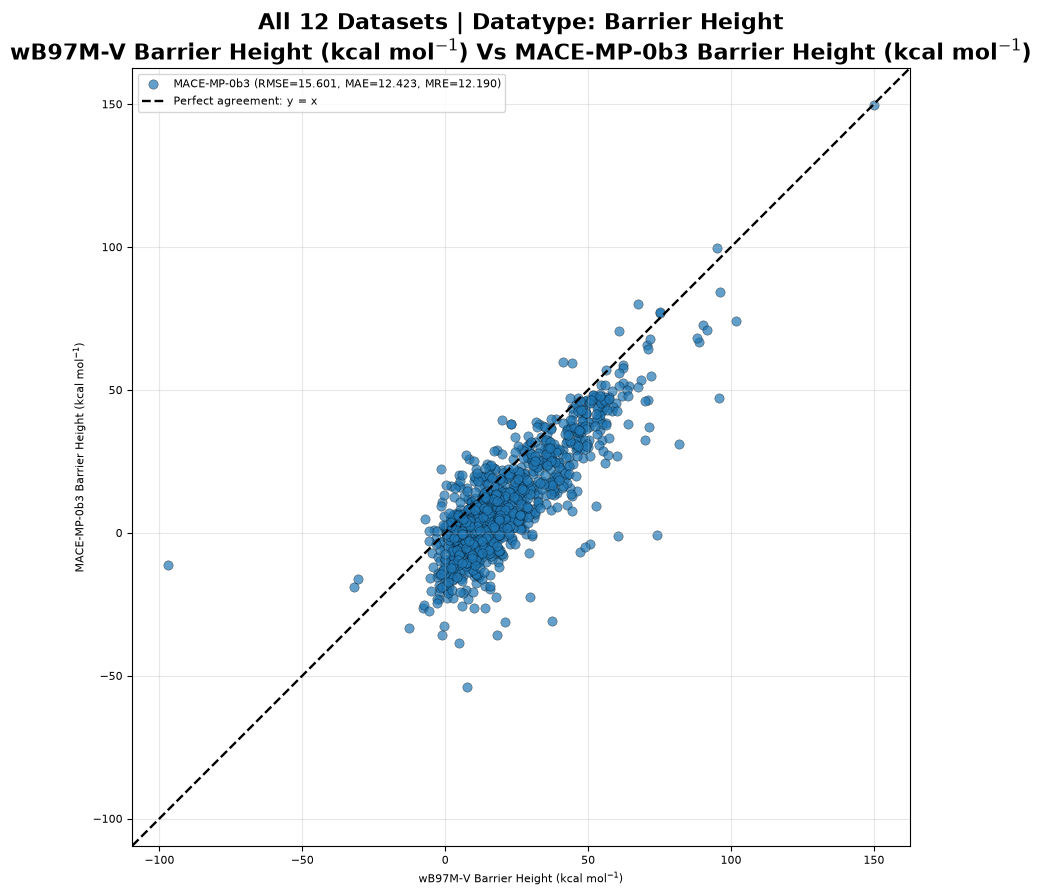

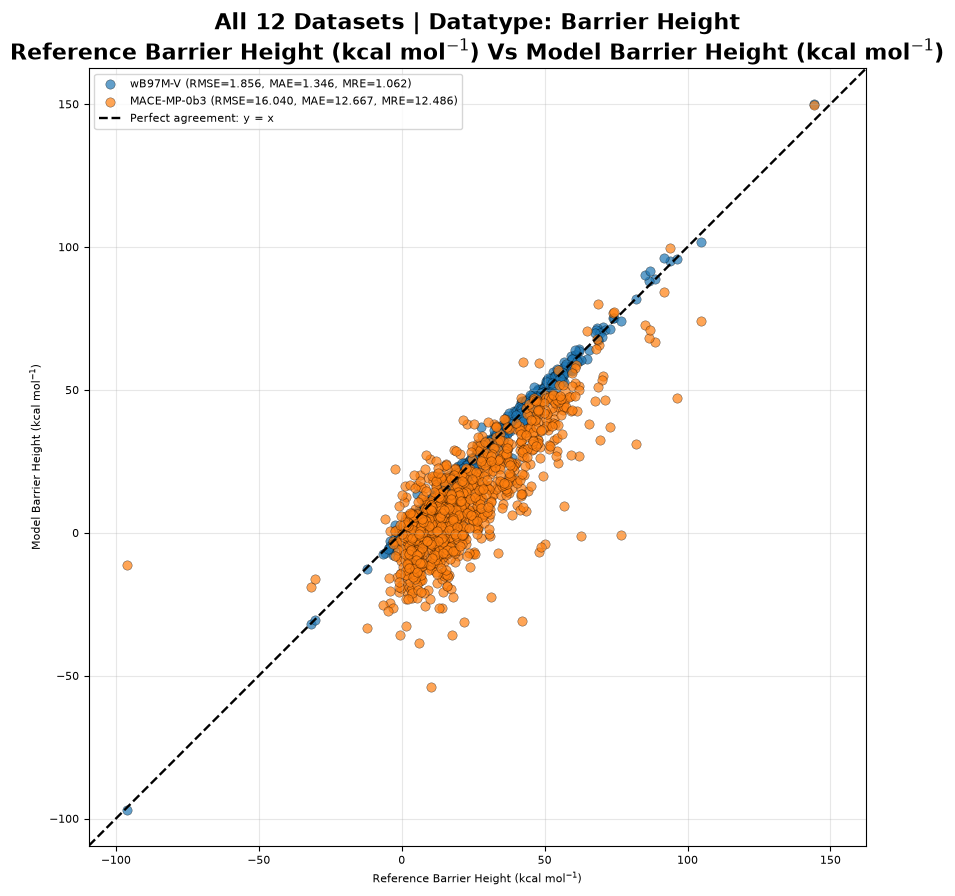

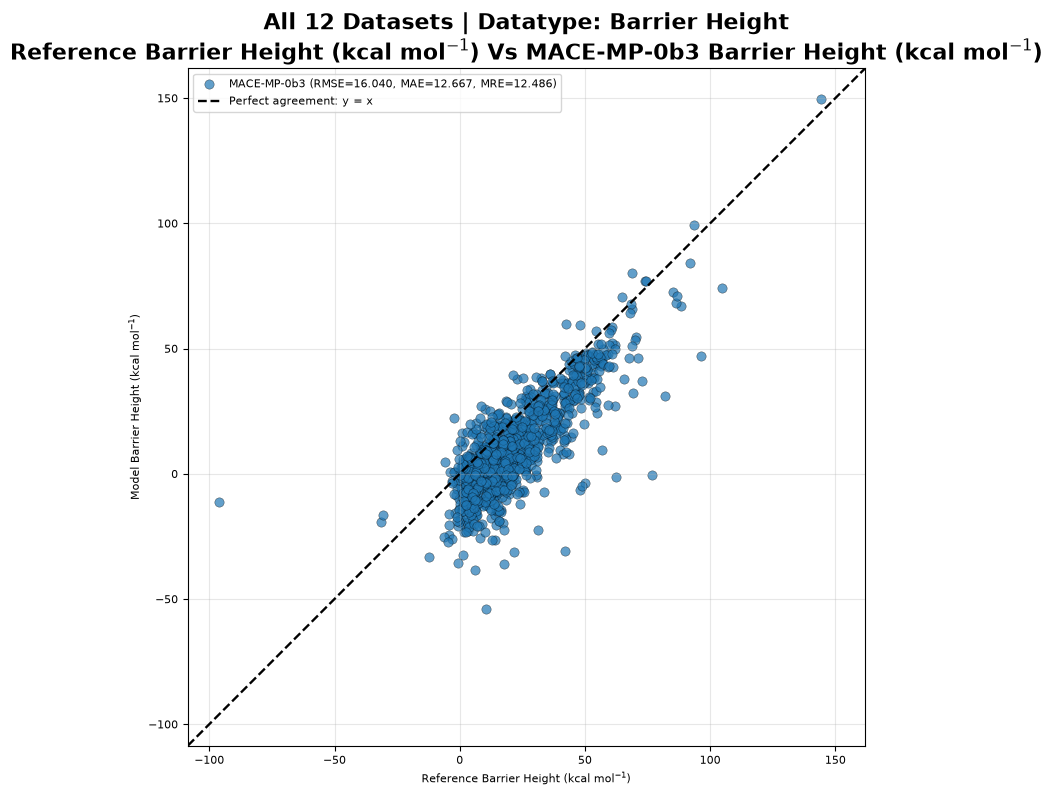

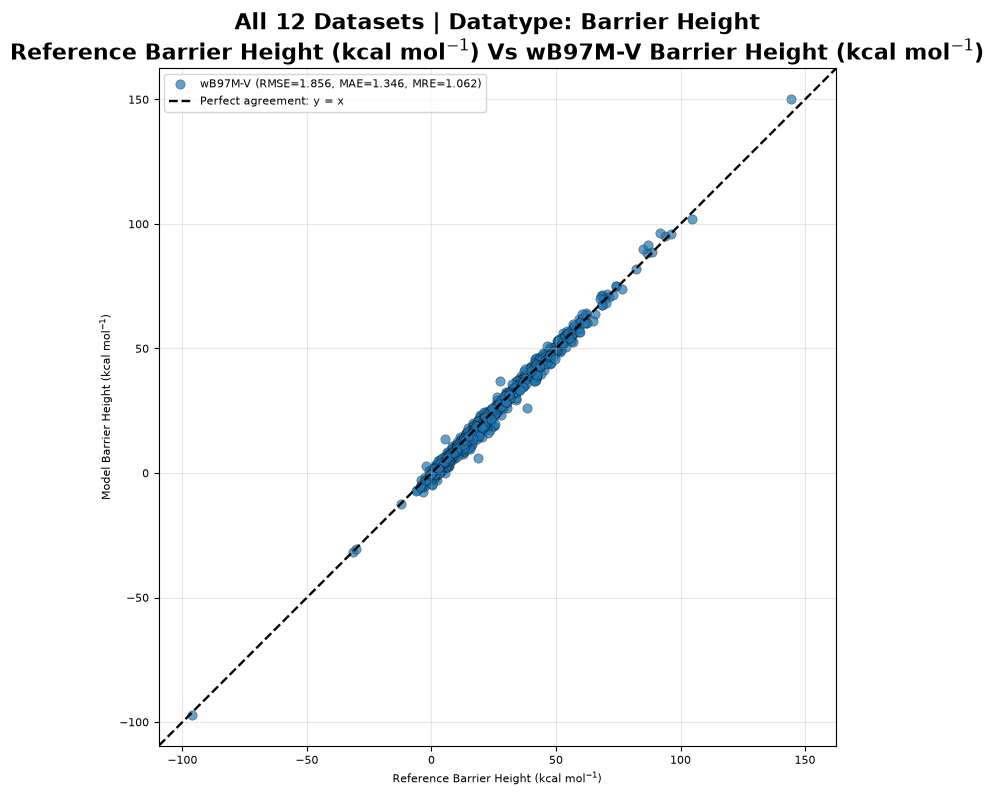

In [8]:
# CELL 2 — Barrier Height correlation plots

import matplotlib.pyplot as plt

FIG = A/"Figures"
FIG.mkdir(exist_ok=True)
UNIT = r"kcal mol$^{-1}$"

def metrics(x, y):
    d = results_df[["Dataset", x, y]].dropna()
    e = d[y] - d[x]
    mre = np.mean([
        np.mean(np.abs(g[y] - g[x])) / std.loc[ds]
        for ds, g in d.groupby("Dataset")
    ])
    return np.sqrt(np.mean(e**2)), np.mean(np.abs(e)), mre

def plot(x, ys, file, xlabel, ylabel, title, size=(12, 9)):
    fig, ax = plt.subplots(figsize=size)
    vals = [results_df[x]]

    for y in ys:
        rmse, mae, mre = metrics(x, y)
        ax.scatter(
            results_df[x], results_df[y], s=45, alpha=.7,
            edgecolors="black", linewidths=.3,
            label=f"{y} (RMSE={rmse:.3f}, MAE={mae:.3f}, MRE={mre:.3f})"
        )
        vals.append(results_df[y])

    v = np.concatenate([a.dropna().to_numpy() for a in vals])
    lo, hi = v.min(), v.max()
    p = .05 * (hi - lo)

    ax.plot([lo-p, hi+p], [lo-p, hi+p], "k--", lw=1.7,
            label="Perfect agreement: y = x")
    ax.set(xlim=(lo-p, hi+p), ylim=(lo-p, hi+p),
           xlabel=xlabel, ylabel=ylabel)
    ax.set_title(f"All {len(sets)} Datasets | Datatype: {DATATYPE}\n{title}",
                 fontsize=16, fontweight="bold")
    ax.grid(alpha=.3)
    ax.legend(loc="upper left")
    ax.set_aspect("equal", adjustable="box")
    plt.tight_layout()
    plt.savefig(FIG/file, dpi=300, bbox_inches="tight")
    plt.show()

# 1. wB97M-V vs MACE-MP-0b3
plot(
    "wB97M-V", [MODEL],
    "1_Barrier_Height_wB97M-V_vs_MACE-MP-0b3.png",
    f"wB97M-V Barrier Height ({UNIT})",
    f"MACE-MP-0b3 Barrier Height ({UNIT})",
    f"wB97M-V Barrier Height ({UNIT}) Vs MACE-MP-0b3 Barrier Height ({UNIT})"
)

# 2. Reference vs all models
plot(
    "Reference", ["wB97M-V", MODEL],
    "2_Barrier_Height_Reference_vs_All_Models.png",
    f"Reference Barrier Height ({UNIT})",
    f"Model Barrier Height ({UNIT})",
    f"Reference Barrier Height ({UNIT}) Vs Model Barrier Height ({UNIT})"
)

# 3. Reference vs MACE-MP-0b3
plot(
    "Reference", [MODEL],
    "3_Barrier_Height_Reference_vs_MACE-MP-0b3.png",
    f"Reference Barrier Height ({UNIT})",
    f"Model Barrier Height ({UNIT})",
    f"Reference Barrier Height ({UNIT}) Vs MACE-MP-0b3 Barrier Height ({UNIT})",
    (10, 8)
)

# 4. Reference vs wB97M-V
plot(
    "Reference", ["wB97M-V"],
    "4_Barrier_Height_Reference_vs_wB97M-V.png",
    f"Reference Barrier Height ({UNIT})",
    f"Model Barrier Height ({UNIT})",
    f"Reference Barrier Height ({UNIT}) Vs wB97M-V Barrier Height ({UNIT})",
    (10, 8)
)